# ♻️ EcoSort_AI
## Smart Waste Classification Using Deep Learning

## **Developed By:** JYOTHSNA

## Project Objective

### The objective of this project is to build a Custom Convolutional Neural Network (CNN) 
### that automatically classifies waste images into different categories.

### The trained model helps in identifying the waste type and can be integrated into a smart waste 
### management system for proper waste segregation.

## Import Required Libraries

In [1]:
# Numerical Computation
import numpy as np

# File Handling
import os

# Image Processing
import cv2

# Data Visualization
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf

# TensorFlow Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Image Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Class Weights
from sklearn.utils.class_weight import compute_class_weight

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## Project Configuration

### Set the project parameters such as image size, batch size, number of epochs, and dataset path.

In [2]:
# Image Size
IMG_HEIGHT = 160
IMG_WIDTH = 160

# Batch Size
BATCH_SIZE = 32

# Epochs
EPOCHS = 25

# Dataset Path
DATASET_PATH = "../dataset/garbage_classification"

In [3]:
print("Image Size :", IMG_HEIGHT, "x", IMG_WIDTH)
print("Batch Size :", BATCH_SIZE)
print("Epochs :", EPOCHS)
print("Dataset Path :", DATASET_PATH)

Image Size : 160 x 160
Batch Size : 32
Epochs : 25
Dataset Path : ../dataset/garbage_classification


## Explore Dataset

### Read the dataset folder and display all available waste categories.

In [4]:
categories = sorted(os.listdir(DATASET_PATH))

print("Categories Found:\n")

for category in categories:
    print(category)

print("\nTotal Categories :", len(categories))

Categories Found:

battery
biological
brown-glass
cardboard
clothes
green-glass
metal
paper
plastic
shoes
trash
white-glass

Total Categories : 12


## Count Images in Each Category

### Count the number of images available in each waste category.

In [5]:
total_images = 0

for category in categories:

    folder = os.path.join(DATASET_PATH, category)

    count = len(os.listdir(folder))

    print(f"{category:<15} : {count}")

    total_images += count

print("\nTotal Images :", total_images)

battery         : 945
biological      : 985
brown-glass     : 607
cardboard       : 891
clothes         : 5325
green-glass     : 629
metal           : 769
paper           : 1050
plastic         : 865
shoes           : 1977
trash           : 697
white-glass     : 775

Total Images : 15515


## Visualize Sample Images

### Display one sample image from each category to verify that the dataset has been loaded correctly.

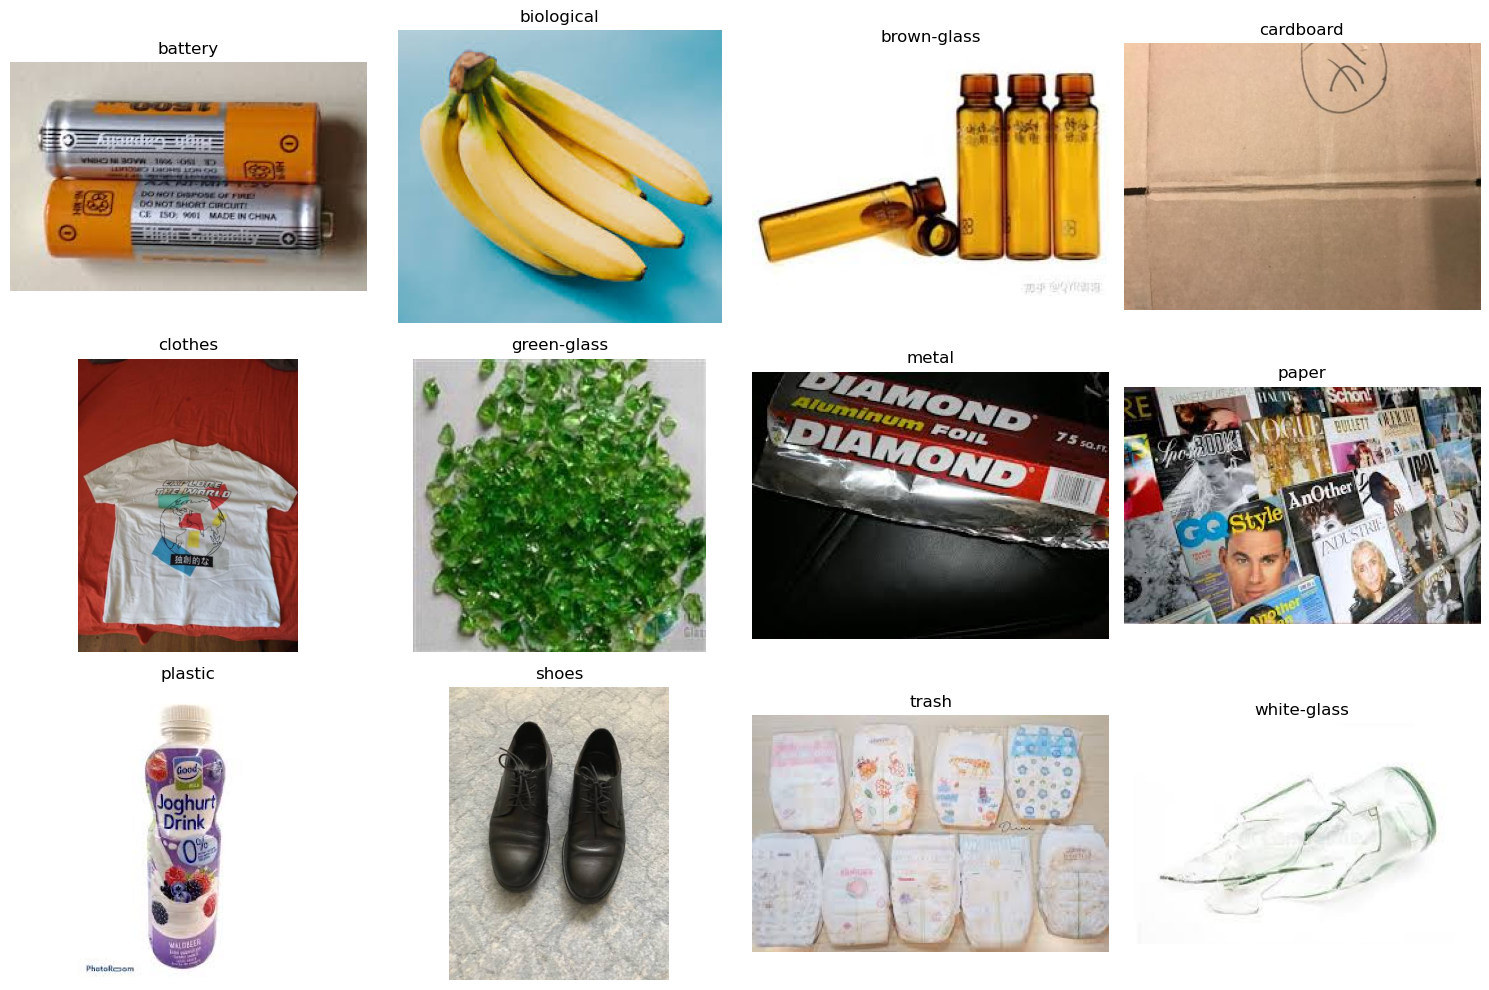

In [6]:
plt.figure(figsize=(15,10))

for i, category in enumerate(categories):

    folder = os.path.join(DATASET_PATH, category)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)

    plt.imshow(image)

    plt.title(category)

    plt.axis("off")

plt.tight_layout()

plt.show()

## Data Augmentation

### Data augmentation improves the diversity of the training dataset by applying random transformations to the images.

## The following techniques are used:
### - Rescaling
### - Rotation
### - Zoom
### - Horizontal Flip
### - Width Shift
### - Height Shift

In [7]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.20,

    rotation_range=20,

    zoom_range=0.20,

    horizontal_flip=True,

    width_shift_range=0.20,

    height_shift_range=0.20,

    fill_mode="nearest"
)

## Create Training and Validation Generators

### The dataset is divided into:
### - 80% Training Data
### - 20% Validation Data

In [8]:
train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training",

    shuffle=True
)

Found 12415 images belonging to 12 classes.


In [9]:
validation_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation",

    shuffle=False
)

Found 3100 images belonging to 12 classes.


## Display Class Labels

## Display the numerical labels assigned to each waste category.

In [10]:
print("Class Labels:\n")

for class_name, index in train_generator.class_indices.items():
    print(f"{index} : {class_name}")

Class Labels:

0 : battery
1 : biological
2 : brown-glass
3 : cardboard
4 : clothes
5 : green-glass
6 : metal
7 : paper
8 : plastic
9 : shoes
10 : trash
11 : white-glass


##  Calculate Class Weights

### The dataset contains an unequal number of images in different waste categories.

### To reduce the effect of class imbalance, class weights are calculated. During training, 
### these weights help the model pay more attention to classes with fewer images.

In [11]:
# Get training labels
labels = train_generator.classes

print("Total Training Images :", len(labels))

Total Training Images : 12415


In [12]:
# Calculate Class Weights

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:\n")

for key, value in class_weights.items():
    print(f"Class {key} : {value:.2f}")

Class Weights:

Class 0 : 1.37
Class 1 : 1.31
Class 2 : 2.13
Class 3 : 1.45
Class 4 : 0.24
Class 5 : 2.05
Class 6 : 1.68
Class 7 : 1.23
Class 8 : 1.50
Class 9 : 0.65
Class 10 : 1.85
Class 11 : 1.67


## Build the Improved Custom CNN Model

### A Custom Convolutional Neural Network (CNN) is built from scratch for waste image classification.

## Model Architecture

### - Convolution Block 1 (32 Filters)
### - Convolution Block 2 (64 Filters)
### - Convolution Block 3 (128 Filters)
### - Convolution Block 4 (256 Filters)
### - Flatten Layer
### - Dense Layer (512 Units)
### - Dropout Layer
### - Output Layer (12 Classes)

In [13]:
model = Sequential([

    # Block 1
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(
        256,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Flatten
    Flatten(),

    # Dense Layer
    Dense(
        512,
        activation='relu'
    ),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(
        train_generator.num_classes,
        activation='softmax'
    )

])

## Display Model Summary

### The model summary displays:

### - Layer Names
### - Output Shapes
### - Number of Trainable Parameters
### - Total Parameters

### This helps verify that the CNN architecture has been created correctly.

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 158, 158, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 158, 158, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 79, 79, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 77, 77, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 77, 77, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 36, 36, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 36, 36, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       8,389,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │           6,156 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,785,612 (33.51 MB)

 Trainable params: 8,784,652 (33.51 MB)

 Non-trainable params: 960 (3.75 KB)

## Compile the CNN Model

## The model is compiled using:

### - Optimizer : Adam
### - Loss Function : Categorical Crossentropy
### - Evaluation Metric : Accuracy

In [15]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


## Configure Training Callbacks

### Two callbacks are used during training.

## EarlyStopping

### Stops training automatically if the validation loss does not improve.

## ReduceLROnPlateau

### Reduces the learning rate whenever the validation loss stops improving, allowing the optimizer to converge more effectively.

In [16]:
early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=4,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    min_lr=0.000001,

    verbose=1

)

## Train the CNN Model

### The CNN model is trained using:

### - Training Dataset
### - Validation Dataset
### - Class Weights
### - EarlyStopping
### - ReduceLROnPlateau

### The maximum number of training epochs is 25. However, EarlyStopping may stop training earlier if the validation loss does not improve.

In [17]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=25,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1

)

Epoch 1/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 497s 1s/step - accuracy: 0.2861 - loss: 3.6925 - val_accuracy: 0.2990 - val_loss: 2.2098 - learning_rate: 0.0010
Epoch 2/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - accuracy: 0.3856 - loss: 1.9088 - val_accuracy: 0.5042 - val_loss: 1.5735 - learning_rate: 0.0010
Epoch 3/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 472s 1s/step - accuracy: 0.4246 - loss: 1.7854 - val_accuracy: 0.3106 - val_loss: 2.2960 - learning_rate: 0.0010
Epoch 4/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4474 - loss: 1.7095
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
388/388 ━━━━━━━━━━━━━━━━━━━━ 471s 1s/step - accuracy: 0.4474 - loss: 1.7095 - val_accuracy: 0.4490 - val_loss: 1.8375 - learning_rate: 0.0010
Epoch 5/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 485s 1s/step - accuracy: 0.4917 - loss: 1.5532 - val_accuracy: 0.5232 - val_loss: 1.4363 - learning_rate: 5.0000e-04
Epoch 6/25
388/388 ━━━━━━━━━━━━━━━━━━━━ 470s 1s/step - accuracy: 0.5161 - loss: 1

## Visualize Model Performance

### After training the CNN model, the training history is visualized using accuracy and loss graphs.

### These graphs help analyze:
### - Model learning progress
### - Overfitting or underfitting
### - Training and validation performance

## Plot Training and Validation Accuracy

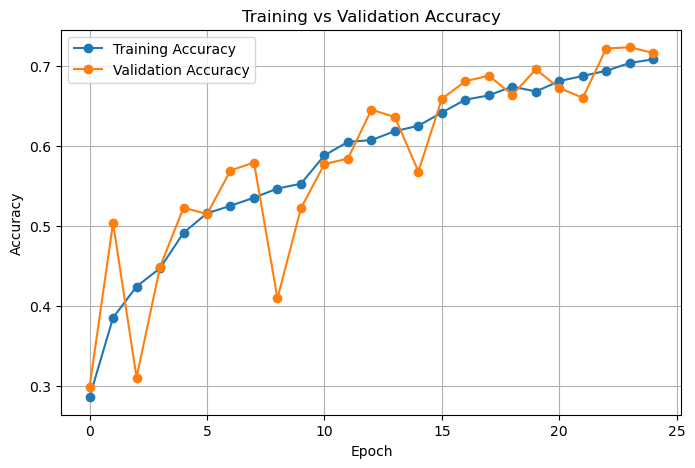

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         marker='o',
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         marker='o',
         label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

## Plot Training and Validation Loss

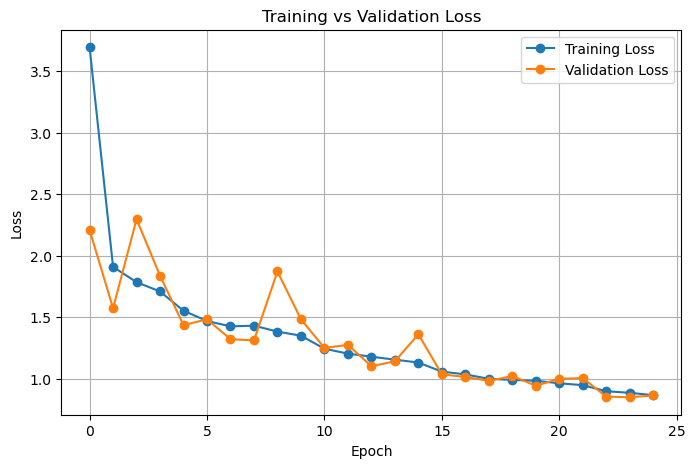

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         marker='o',
         label='Training Loss')

plt.plot(history.history['val_loss'],
         marker='o',
         label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

## Evaluate the Model

### The trained CNN model is evaluated on the validation dataset.

### The evaluation provides:

### - Validation Loss
### - Validation Accuracy

### These metrics indicate how well the model performs on unseen waste images.

In [20]:
loss, accuracy = model.evaluate(validation_generator)

print(f"\nValidation Loss     : {loss:.4f}")

print(f"Validation Accuracy : {accuracy*100:.2f}%")

97/97 ━━━━━━━━━━━━━━━━━━━━ 37s 385ms/step - accuracy: 0.7213 - loss: 0.8562

Validation Loss     : 0.8562
Validation Accuracy : 72.13%


## Generate Predictions

### The trained CNN model predicts the waste category for each image in the validation dataset.

### These predictions are used to create the confusion matrix and classification report.

In [21]:
# Reset Generator

validation_generator.reset()

# Predict

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 395ms/step


## Confusion Matrix

### The confusion matrix compares the actual class labels with the predicted labels.

### It helps identify correctly classified and misclassified waste categories.

<Figure size 1000x1000 with 0 Axes>

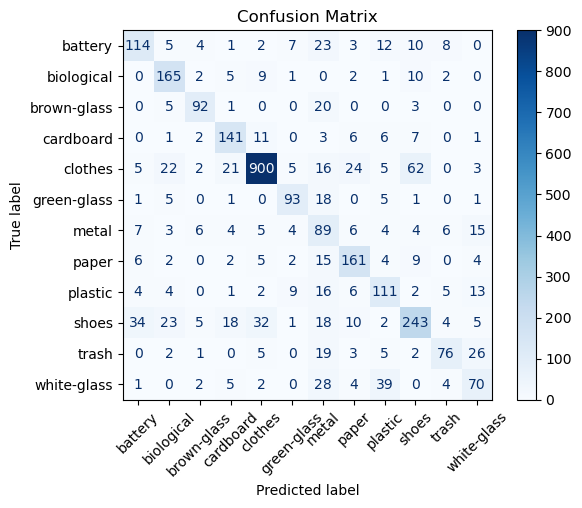

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create Confusion Matrix

cm = confusion_matrix(true_classes, predicted_classes)

# Display

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

plt.figure(figsize=(10,10))

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.show()

## Classification Report

### The classification report provides detailed performance metrics for each waste category.

## Metrics include:

### - Precision
### - Recall
### - F1-Score
### - Support

In [23]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

     battery       0.66      0.60      0.63       189
  biological       0.70      0.84      0.76       197
 brown-glass       0.79      0.76      0.78       121
   cardboard       0.70      0.79      0.75       178
     clothes       0.92      0.85      0.88      1065
 green-glass       0.76      0.74      0.75       125
       metal       0.34      0.58      0.43       153
       paper       0.72      0.77      0.74       210
     plastic       0.57      0.64      0.60       173
       shoes       0.69      0.62      0.65       395
       trash       0.72      0.55      0.62       139
 white-glass       0.51      0.45      0.48       155

    accuracy                           0.73      3100
   macro avg       0.67      0.68      0.67      3100
weighted avg       0.75      0.73      0.73      3100



## Save the Trained CNN Model

### After successful training, the trained CNN model is saved in the Keras (.keras) format.

### Saving the model allows it to be reused later without retraining. The saved model will be used 
### in the Streamlit web application for waste image prediction.

In [24]:
# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Model
model.save("../models/garbage_classifier_model.keras")

print("Model saved successfully!")

Model saved successfully!


## Load the Saved Model

### The saved CNN model is loaded from disk. This demonstrates that the trained model can be reused without training again.

In [25]:
from tensorflow.keras.models import load_model

loaded_model = load_model("../models/garbage_classifier_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


## Predict a Single Waste Image

### The trained CNN model predicts the category of a single waste image.

## Prediction Steps:

### 1. Load image
### 2. Resize image
### 3. Normalize pixel values
### 4. Predict category
### 5. Display confidence score

In [27]:
# Path of Test Image
image_path = r"C:\Users\jyoth\OneDrive\Desktop\EcoSort_AI\dataset\garbage_classification\plastic\plastic7.jpg"

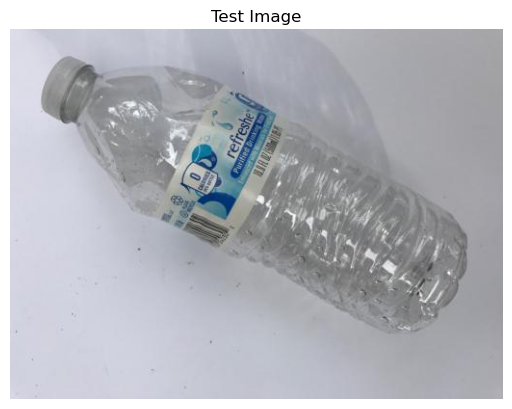

In [28]:
# Read Image

image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)

plt.title("Test Image")

plt.axis("off")

plt.show()

In [29]:
# Resize Image

test_image = cv2.resize(image_rgb, (IMG_WIDTH, IMG_HEIGHT))

test_image = test_image / 255.0

test_image = np.expand_dims(test_image, axis=0)

In [30]:
# Predict

prediction = loaded_model.predict(test_image)

predicted_index = np.argmax(prediction)

confidence = np.max(prediction)

predicted_class = class_labels[predicted_index]

print("Predicted Class :", predicted_class)

print("Confidence :", f"{confidence*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
Predicted Class : plastic
Confidence : 95.26%


## Waste Bin Recommendation

### After predicting the waste category, the application recommends the appropriate waste disposal bin.

In [31]:
# Waste Bin Mapping

bin_mapping = {

    "battery": "🟥 Hazardous Waste Bin",

    "biological": "🟩 Organic Waste Bin",

    "brown-glass": "🟨 Glass Recycling Bin",

    "cardboard": "🟦 Dry Waste Recycling Bin",

    "clothes": "🟪 Textile Recycling Bin",

    "green-glass": "🟨 Glass Recycling Bin",

    "metal": "⚪ Metal Recycling Bin",

    "paper": "🔵 Paper Recycling Bin",

    "plastic": "🟠 Plastic Recycling Bin",

    "shoes": "🟪 Textile Recycling Bin",

    "trash": "⚫ General Waste Bin",

    "white-glass": "🟨 Glass Recycling Bin"

}

print("Recommended Bin :", bin_mapping[predicted_class])

Recommended Bin : 🟠 Plastic Recycling Bin


#  Project Conclusion

## The EcoSort_AI system successfully classifies waste images into twelve categories using a Custom Convolutional Neural Network.

## The trained model can identify different types of waste and recommend the appropriate disposal bin, supporting smart waste segregation and recycling practices.

## This project demonstrates the practical application of Deep Learning in environmental sustainability.